In [1]:
import pandas as pd
import numpy as np
import glob, os, shutil, cv2, json, sys
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import scipy.ndimage as ndimage
from tqdm import tqdm


def getFiles(path, limit=None, shuffle=False):
    target = sorted(glob.glob(os.path.join(path, '*')))
    if shuffle:
        np.random.shuffle(target) 
    return target[:limit]

def formatAxis(img):
    return np.transpose(img, (0, 2, 1))

def setFolder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)

def showTile(img, mask=False):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    mid_x = img.shape[0] // 2
    mid_y = img.shape[1] // 2
    mid_z = img.shape[2] // 2

    slices = [
        img[mid_x, :, :],  # Plano YZ (Corte ao longo do eixo X)
        img[:, mid_y, :],  # Plano XZ (Corte ao longo do eixo Y)
        img[:, :, mid_z]   # Plano XY (Corte ao longo do eixo Z)
    ]

    slices[0] = np.array(slices[0])
    arr_y = np.array(slices[1])
    arr_z = np.array(slices[2])
    slices[1] = np.rot90(arr_z, -1)
    slices[2] = arr_y

    cmap_config = ListedColormap(['black', 'red', 'green', 'blue']) if mask else 'gray'
    vmin, vmax  = (0, 3) if mask else (None, None)
    titles = [f'Slice X={mid_x}', f'Slice Y={mid_y}', f'Slice Z={mid_z}']
    
    for i, ax in enumerate(axes):
        ax.imshow(slices[i], cmap=cmap_config, vmin=vmin, vmax=vmax)
        ax.set_title(titles[i])
    
    plt.tight_layout()
    plt.show()

### Variáveis que melhoram a qualidade/nitidez
- self.waveletFreq = (45, 65)    # Frequência alta = nitidez
- self.noiseLevel = (0.0, 0.01)  # Quase zero ruído
- self.layerThickness = (1, 3)   # Camadas finas
- self.faultRoughness = 1.0      # Falhas mais limpas e retas

In [2]:
import os
import shutil
import numpy as np
import scipy.ndimage as ndimage
from tqdm import tqdm


def getFiles(path, limit=None, shuffle=False):
    import glob
    target = sorted(glob.glob(os.path.join(path, '*')))
    if shuffle:
        np.random.shuffle(target)
    return target[:limit]


def formatAxis(img):
    return np.transpose(img, (0, 2, 1))


def setFolder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)


class SyntheticGenerator:

    def __init__(self, shape=(128, 128, 128)):
        self.margin = 64
        self.zoom   = 1.8
        self.finalShape = shape
        self.zoom = max(self.zoom, 0.1)

        # ── Reflectivity (Stratigraphy) ──────────────────────────
        self.layerRange = (80, 160)
        self.layerThickness = (1, 4)
        self.layerNoise = 0.01

        # ── Folding ──────────────────────────────────────────────
        self.foldCount = (15, 30)
        self.foldSigma = (15, 80)
        self.foldAmplitude = (-30, 30)
        self.foldDamping = 1.5
        self.foldBaseShift = (-3, 3)

        # ── Shearing ─────────────────────────────────────────────
        self.shearOffset = (-5, 5)
        self.shearGradient = (-0.1, 0.1)

        # ── Faulting ─────────────────────────────────────────────
        self.faultCount = (4, 7)
        self.faultThrow = (5, 35)
        self.faultDipAngle = (20, 75)

        self.faultRoughness = 6.0
        self.faultRoughSigma = 8
        self.faultDecaySigma = (60, 150)
        self.faultZoneWidth = 2.0
        self.faultThreshold = 0.5
        self.faultCurveProb = 0.35
        self.faultCurveMax = 20.0

        # ── Wavelet ──────────────────────────────────────────────
        self.waveletFreq = (45, 65)
        self.waveletDuration = 0.08
        self.waveletDt = 0.002

        # ── Noise ────────────────────────────────────────────────
        self.noiseLevel = (0.00, 0.05)

        # ── Internal working volume ──────────────────────────────
        extraMargin = int(np.ceil(max(shape) * (self.zoom - 1.0) / 2.0)) if self.zoom > 1.0 else 0
        self.nx = shape[0] + 2 * (self.margin + extraMargin)
        self.ny = shape[1] + 2 * (self.margin + extraMargin)
        self.nz = shape[2] + 2 * (self.margin + extraMargin)
        self.shape = (self.nx, self.ny, self.nz)

    def get(self):
        data = self.genReflectivity()
        data = self.applyFolding(data)
        data = self.applyShearing(data)
        data, mask = self.applyFaulting(data)
        image = self.applyWavelet(data)
        image = self.applyNoise(image)

        image = self.crop(image)
        mask = self.crop(mask)
        image = (image - np.mean(image)) / (np.std(image) + 1e-8)
        return image.astype(np.float32), mask.astype(np.uint8)

    def dataset(self, n=200, outputDir="output"):
        imgDir = os.path.join(outputDir, "images")
        mskDir = os.path.join(outputDir, "masks")
        setFolder(imgDir)
        setFolder(mskDir)

        for i in tqdm(range(n), desc="Generating dataset"):
            image, mask = self.get()
            image, mask = formatAxis(image), formatAxis(mask)

            np.save(os.path.join(imgDir, f"img_{i:04d}.npy"), image)
            np.save(os.path.join(mskDir, f"img_{i:04d}.npy"), mask)

    def genReflectivity(self):
        r1d = np.zeros(self.nz)
        nLayers = np.random.randint(*self.layerRange)

        for _ in range(nLayers):
            pos = np.random.randint(0, self.nz)
            thickness = np.random.randint(*self.layerThickness)
            r1d[pos : pos + thickness] = np.random.uniform(-1, 1)

        r1d += np.random.normal(0, self.layerNoise, self.nz)
        r3d = np.tile(r1d, (self.nx, self.ny, 1))

        noise3d = np.random.normal(0, 1, self.shape)
        smoothedNoise = ndimage.gaussian_filter(noise3d, sigma=(1.0, 1.0, 0.0))
        smoothedNoise *= (self.layerNoise * 10 / (np.std(smoothedNoise) + 1e-8))

        return r3d + smoothedNoise

    def applyFolding(self, reflectivity):
        x = np.arange(self.nx)
        y = np.arange(self.ny)
        xx, yy = np.meshgrid(x, y, indexing="ij")

        a0 = np.random.uniform(*self.foldBaseShift)
        nGaussians = np.random.randint(*self.foldCount)
        shift2d = np.zeros((self.nx, self.ny))

        for _ in range(nGaussians):
            x0 = np.random.uniform(-self.nx * 0.3, self.nx * 1.3)
            y0 = np.random.uniform(-self.ny * 0.3, self.ny * 1.3)
            sigmaX = np.random.uniform(*self.foldSigma)
            sigmaY = np.random.uniform(*self.foldSigma)
            theta = np.random.uniform(0, np.pi)
            amp = np.random.uniform(*self.foldAmplitude)

            dx = xx - x0
            dy = yy - y0
            cosT, sinT = np.cos(theta), np.sin(theta)
            u = cosT * dx + sinT * dy
            v = -sinT * dx + cosT * dy
            shift2d += amp * np.exp(-(u**2 / (2 * sigmaX**2) + v**2 / (2 * sigmaY**2)))

        zGrid = np.arange(self.nz)
        damping = np.exp(-self.foldDamping * zGrid / (self.nz - 1))

        s1 = a0 + shift2d[:, :, np.newaxis] * damping

        ix, iy, iz = np.indices(self.shape)
        return ndimage.map_coordinates(reflectivity, [ix, iy, iz + s1], order=3, mode="nearest")

    def applyShearing(self, reflectivity):
        e0 = np.random.uniform(*self.shearOffset)
        f = np.random.uniform(*self.shearGradient)
        g = np.random.uniform(*self.shearGradient)

        ix, iy, iz = np.indices(self.shape)
        s2 = e0 + f * ix + g * iy
        return ndimage.map_coordinates(reflectivity, [ix, iy, iz + s2], order=3, mode="nearest")

    def applyFaulting(self, reflectivity):
        masks = np.zeros(self.shape, dtype=np.uint8)
        model = np.copy(reflectivity)

        numFaults = np.random.randint(*self.faultCount)
        ix, iy, iz = np.indices(self.shape)

        for i in range(numFaults):
            p0 = np.random.uniform(0.15, 0.85, 3) * np.array(self.shape)

            dipAngle = np.random.uniform(*self.faultDipAngle)
            dipRad = np.deg2rad(dipAngle)
            strikeRad = np.random.uniform(0, 2 * np.pi)
            fnx = np.sin(dipRad) * np.cos(strikeRad)
            fny = np.sin(dipRad) * np.sin(strikeRad)
            fnz = np.cos(dipRad)
            normal = np.array([fnx, fny, fnz])

            strike = np.array([-normal[1], normal[0], 0.0])
            strikeNorm = np.linalg.norm(strike)
            strike = np.array([1.0, 0.0, 0.0]) if strikeNorm < 1e-6 else strike / strikeNorm
            dip = np.cross(normal, strike)
            dip /= np.linalg.norm(dip)

            dx = ix - p0[0]
            dy = iy - p0[1]
            dz = iz - p0[2]

            distStrike = strike[0] * dx + strike[1] * dy + strike[2] * dz
            distDip = dip[0] * dx + dip[1] * dy + dip[2] * dz
            bend = 0.0

            if np.random.random() < self.faultCurveProb:
                maxDist = max(self.shape) / 1.5
                baseIntensity = np.random.uniform(self.faultCurveMax * 0.5, self.faultCurveMax)
                direction = np.random.choice([-1.0, 1.0])
                curveIntensity = baseIntensity * direction
                bend = curveIntensity * ((distDip / maxDist) ** 2)

            smallShape = tuple(s // 4 + 1 for s in self.shape)
            noiseSmall = np.random.normal(0, 1, smallShape)
            noiseSmall = ndimage.gaussian_filter(noiseSmall, sigma=self.faultRoughSigma / 4.0)
            noisePlane = ndimage.zoom(
                noiseSmall,
                [s1 / s2 for s1, s2 in zip(self.shape, smallShape)],
                order=1
            ) * self.faultRoughness

            distPlane = normal[0] * dx + normal[1] * dy + normal[2] * dz + noisePlane - bend
            maxDisp = np.random.uniform(*self.faultThrow)
            throwMap = self.computeThrowMap(distStrike, distDip, maxDisp)

            izShifted = iz.astype(float)
            izShifted[distPlane > 0] -= throwMap[distPlane > 0]

            model = ndimage.map_coordinates(model, [ix, iy, izShifted], order=1, mode="nearest")
            faultZone = (np.abs(distPlane) < self.faultZoneWidth) & (np.abs(throwMap) > self.faultThreshold)
            masks[faultZone] = 1

        return model, masks

    def computeThrowMap(self, distStrike, distDip, maxDisp):
        if np.random.random() < 0.5:
            sigmaPlane = np.random.uniform(*self.faultDecaySigma)
            return maxDisp * np.exp(-(distStrike**2 + distDip**2) / (2 * sigmaPlane**2))

        planeExtent = np.sqrt(sum(s**2 for s in self.finalShape)) * 0.5
        direction = np.random.choice([-1, 1])
        return maxDisp * np.clip(0.5 + direction * distDip / planeExtent, 0, 1)

    def applyWavelet(self, model):
        f = np.random.uniform(*self.waveletFreq)
        t = np.arange(-self.waveletDuration, self.waveletDuration, self.waveletDt)
        wavelet = (1 - 2 * (np.pi * f * t) ** 2) * np.exp(-((np.pi * f * t) ** 2))
        return ndimage.convolve1d(model, wavelet, axis=2)

    def applyNoise(self, image):
        scale = np.random.uniform(*self.noiseLevel) * np.std(image)
        noise = np.random.normal(0.0, 1.0, image.shape)
        noise = ndimage.gaussian_filter(noise, sigma=(1.0, 1.0, 0.5))
        noise *= (scale / (np.std(noise) + 1e-8))

        image = image + noise
        image = ndimage.gaussian_filter(image, sigma=(0.3, 0.3, 0))
        return image

    def crop(self, volume):
        fx, fy, fz = self.finalShape
        cx, cy, cz = volume.shape[0] // 2, volume.shape[1] // 2, volume.shape[2] // 2

        ex = int(round(fx * self.zoom / 2.0))
        ey = int(round(fy * self.zoom / 2.0))
        ez = int(round(fz * self.zoom / 2.0))

        x0, x1 = max(cx - ex, 0), min(cx + ex, volume.shape[0])
        y0, y1 = max(cy - ey, 0), min(cy + ey, volume.shape[1])
        z0, z1 = max(cz - ez, 0), min(cz + ez, volume.shape[2])
        cropped = volume[x0:x1, y0:y1, z0:z1]

        if cropped.shape == (fx, fy, fz):
            return cropped

        zoomFactors = (fx / cropped.shape[0], fy / cropped.shape[1], fz / cropped.shape[2])
        order = 0 if volume.dtype == np.uint8 else 3
        return ndimage.zoom(cropped, zoomFactors, order=order)


showing img 0


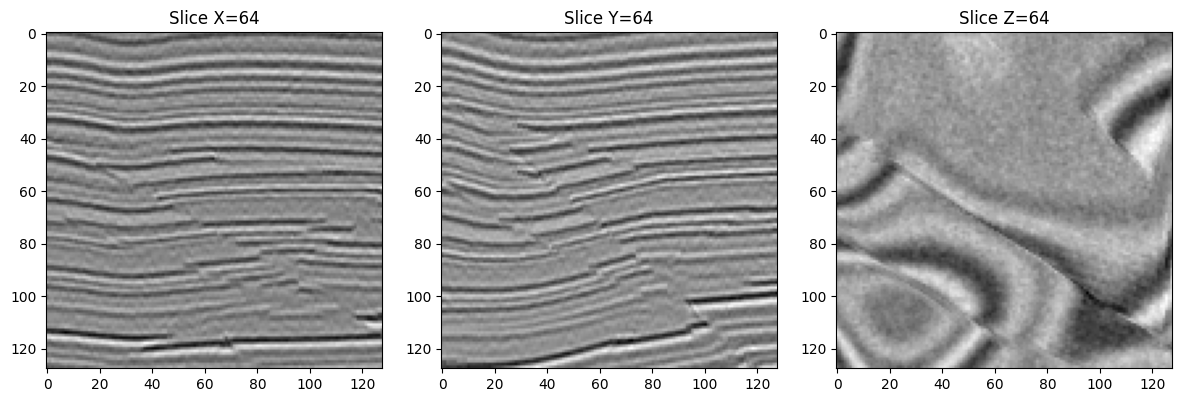

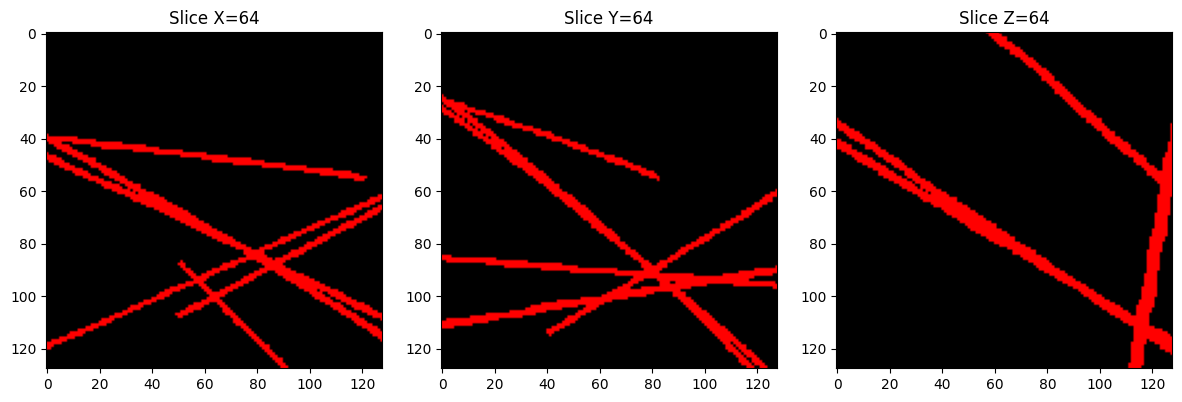




showing img 1


In [ ]:
gen = SyntheticGenerator()

for i in range(2):
    print('showing img', i)
    image, mask = gen.get()    
    image, mask = formatAxis(image), formatAxis(mask)

    showTile(image)
    showTile(mask, mask=True)
    print('\n\n')

# APLICANDO DATASET

In [ ]:
SAVE_DATA = True

In [ ]:
if SAVE_DATA:
    gen = SyntheticGenerator()
    gen.dataset(n=15, outputDir='../Dataset/dataset1/original')

Generating dataset:   7%|▋         | 1/15 [01:17<17:58, 77.04s/it]